# Marketing ROI Analysis Using Simple Linear Regression


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pandas as pd

# Load the Dataset
The dataset was loaded using pandas and inspected to understand its structure.

In [2]:
df = pd.read_csv("marketing_dataset.csv")
df.head()


,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


# Descriptive Statistics
Descriptive statistics were generated to summarize the key characteristics of the dataset. The output provides information on the count, mean, standard deviation, minimum, maximum, and quartile values for each variable. These statistics help in understanding the distribution and scale of the advertising expenditure and sales variables before conducting regression analysis.


In [4]:
df.describe()


,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [5]:
df = df.dropna()

Missing values were identified in all variables. To ensure accurate regression analysis, rows containing missing values were removed using the dropna() function. After cleaning, the dataset contained no missing values.

In [6]:
df.isnull().sum()


TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [7]:
df.shape

(4546, 4)

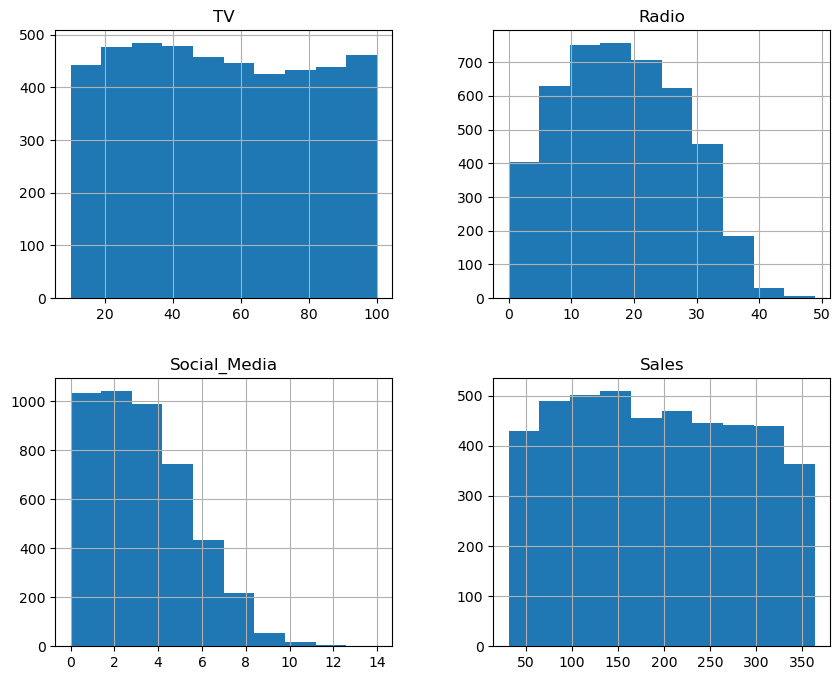

In [8]:
df.hist(figsize=(10, 8))
plt.show()

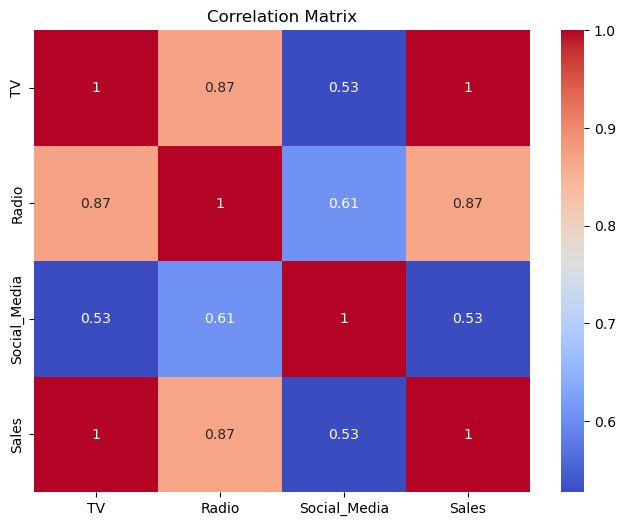

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

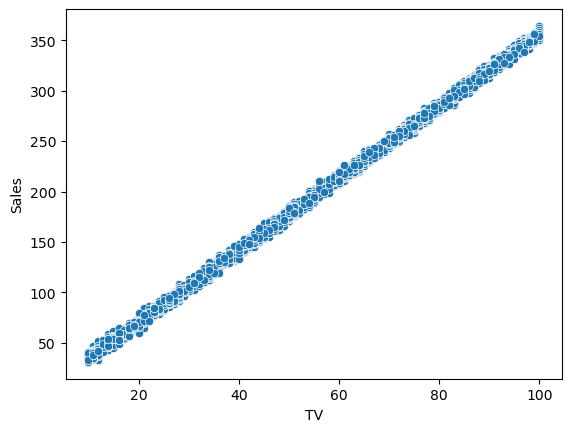

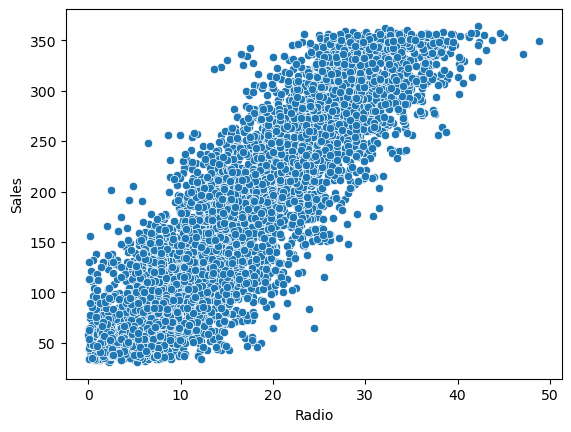

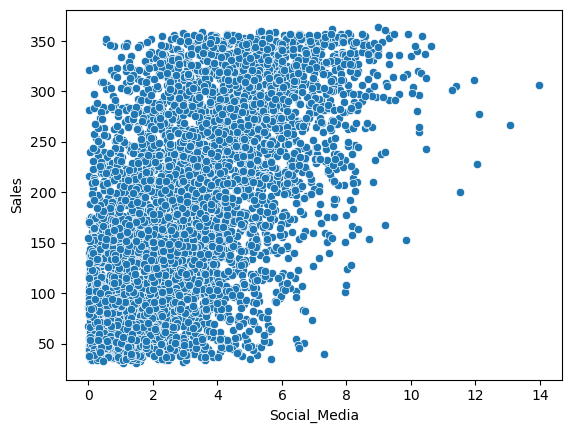

In [10]:
sns.scatterplot(x='TV', y='Sales', data=df)
plt.show()

sns.scatterplot(x='Radio', y='Sales', data=df)
plt.show()

sns.scatterplot(x='Social_Media', y='Sales', data=df)
plt.show()

A correlation analysis was performed to identify the marketing channel most strongly associated with Sales. TV advertising exhibited the highest correlation with Sales (r = 0.9995), indicating an extremely strong positive linear relationship. Therefore, TV was selected as the independent variable for the Simple Linear Regression model.

In [11]:
df.corr()


,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


# Simple Linear Regression Model
An OLS regression model was developed using TV advertising as the predictor variable and Sales as the response variable.

# Model Performance
The regression model achieved an R-squared value of 0.999. This indicates that approximately 99.9% of the variation in Sales can be explained by TV advertising expenditure.
The result suggests an exceptionally strong relationship between TV advertising and Sales.

# Coefficient Interpretation
The coefficient for TV advertising is 3.5615. This indicates that for every additional unit invested in TV advertising, Sales are expected to increase by approximately 3.56 units on average.
The positive coefficient confirms that increased TV advertising expenditure is associated with higher Sales.

# Statistical Significance
The p-value associated with TV advertising is less than 0.05, indicating that TV advertising is a statistically significant predictor of Sales.
Therefore, there is strong statistical evidence that TV advertising expenditure influences Sales.



In [12]:
import statsmodels.api as sm

X = df['TV']
y = df['Sales']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

#



                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        22:51:18   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

In [13]:
predictions = model.predict(X)
residuals = y - predictions

# Residual Analysis
A Residuals vs Fitted plot was generated to evaluate the assumptions of linearity and homoscedasticity.
The residuals appear to be randomly scattered around the zero line without any obvious systematic pattern or curvature. Additionally, the spread of residuals remains relatively constant across the range of fitted values.
These observations suggest that the assumptions of linearity and homoscedasticity are reasonably satisfied, indicating that the linear regression model is appropriate for the data.

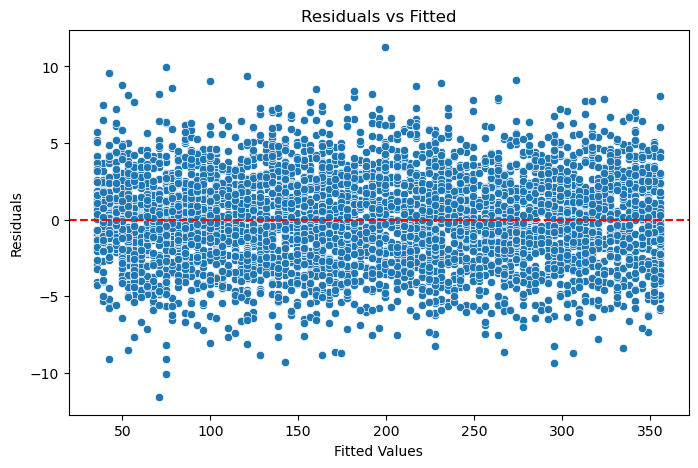

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")

plt.show()



# Normality Assessment
A histogram of the residuals was generated to assess the normality assumption of the regression model.
The residuals exhibit an approximately bell-shaped distribution centered around zero. The distribution appears reasonably symmetric, with no evidence of severe skewness or multiple peaks. Although minor deviations from perfect normality are present, they are not substantial enough to raise concerns about the validity of the model.
Therefore, the normality assumption is considered to be reasonably satisfied.

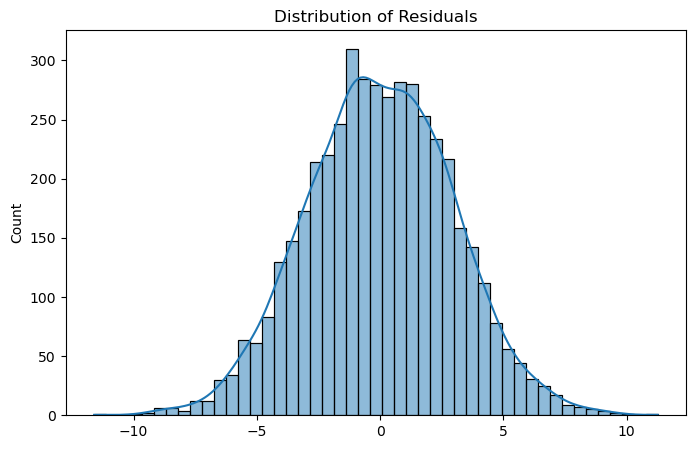

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Distribution of Residuals")

plt.show()



# Q-Q Plot Analysis
A Q-Q plot was generated to further assess the normality of the residuals.
Most of the residuals follow the reference line reasonably closely, indicating that the residual distribution approximates a normal distribution. While minor deviations are visible at the extreme ends of the distribution, these departures are not substantial.
Combined with the histogram of residuals and the normality statistics reported in the regression output, the results suggest that the normality assumption is reasonably satisfied.

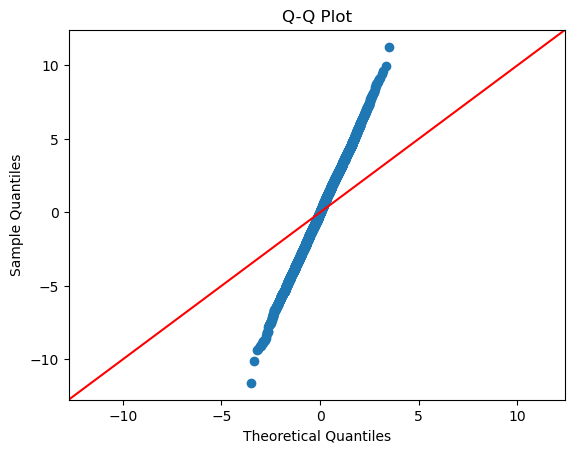

In [16]:
sm.qqplot(residuals, line='45')

plt.title("Q-Q Plot")

plt.show()



# Marketing Budget Recommendation
Based on the correlation analysis and regression results, TV advertising demonstrates the strongest relationship with Sales.
TV advertising achieved the highest correlation with Sales (r = 0.9995) and was found to be a statistically significant predictor of Sales. The regression coefficient indicates that each additional unit invested in TV advertising is associated with an average increase of approximately 3.56 units in Sales.
Therefore, organizations seeking to maximize marketing return on investment (ROI) should prioritize TV advertising as the primary marketing channel. While Radio and Social Media advertising may still contribute to overall marketing performance, TV advertising appears to have the greatest measurable impact on Sales within this dataset.

# Conclusion
This project applied Simple Linear Regression to evaluate the relationship between marketing expenditures and Sales.
After cleaning the dataset and performing exploratory data analysis, TV advertising was identified as the marketing channel most strongly correlated with Sales. A Simple Linear Regression model was then developed using TV advertising as the independent variable.
The model achieved an R-squared value of 0.999, indicating that TV advertising explains approximately 99.9% of the variation in Sales. Diagnostic plots confirmed that the assumptions of linearity, normality, and homoscedasticity were reasonably satisfied.
Overall, the analysis demonstrates that TV advertising is the most effective marketing channel in this dataset and should receive priority when allocating marketing resources.